<h1 align="left">Captions Dataset</h1>

<p align="left"><i>PASTIS24 Dataset</i></p>

<p align="left">
  ITESM
  
  <a href="https://www.linkedin.com/in/juanrtato/">Juan Ricardo Albarracin B.</a>
  <br>
  <a href="">Luis Ángel Oporto Añacato.</a>
  <br>
  <a href="">David Alexis García Espinosa.</a>
  <br>
  <b>Last updated:</b> <i>07/06/2025</i>
  <br><br>
  <a target="_blank">
    <img src="https://github.com/QData/TextAttack/workflows/Github%20PyTest/badge.svg" alt="Testing">
  </a>
  <a href="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000">
    <img src="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000" alt="Version" height="18">
  </a>
</p><br>

In [1]:
PATH_TO_PASTIS = '../datalake/PASTIS24'
PATH_TO_CODE = '../scripts/pastis24'
PATH_TO_FOLDS = '../datalake/PASTIS24/fold-paths'
PATH_TO_PICKLES = '../datalake/PASTIS24/pickle24X24'
CONFIG_PATH = '../datalake/config_vtt.json'
METADATA_PATH = '../datalake/PASTIS24/metadata.geojson'

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
#sys.path.append(PATH_TO_CODE)

In [3]:
import ast
import json
import re
import random
from datetime import datetime, timedelta
from itertools import islice
import plotly.express as px
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import pastis24
from pastis24 import get_dataloaders

from utils import plot_sample_rgb, plot_seg_mask, plot_mean_band_profile, calculate_ndvi_by_crop

In [4]:
with open(METADATA_PATH, 'r') as f:
    metadata_json = json.load(f)

In [5]:
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

In [6]:
with open("../datalake/label_names_en.json", "r") as json_file:
    label_names_en = json.load(json_file)

In [7]:
with open("../datalake/colormap.txt", "r") as txt_file:
    colormap = txt_file.readlines()
colormap = [ast.literal_eval(line.strip().rstrip(',')) for line in colormap]

Set dates formatting to True. This  ensure that the dates in the dataset of captions are formatted correctly, if necessary:

In [8]:
config['DATASETS']['eval']['format_dates'] = True
config['DATASETS']['train']['format_dates'] = True

In [19]:
dataloaders = get_dataloaders(config)

Loading PASTIS2SEQUENCE dataset...
PASTIS2SEQUENCE dataset loaded!


../datalake/PASTIS24/pickle24x24/20450_14.pickle
<re.Match object; span=(0, 15), match='20450_14.pickle'>
Sample shape: (60, 24, 24, 11)
Sample labels shape: (24, 24, 1)


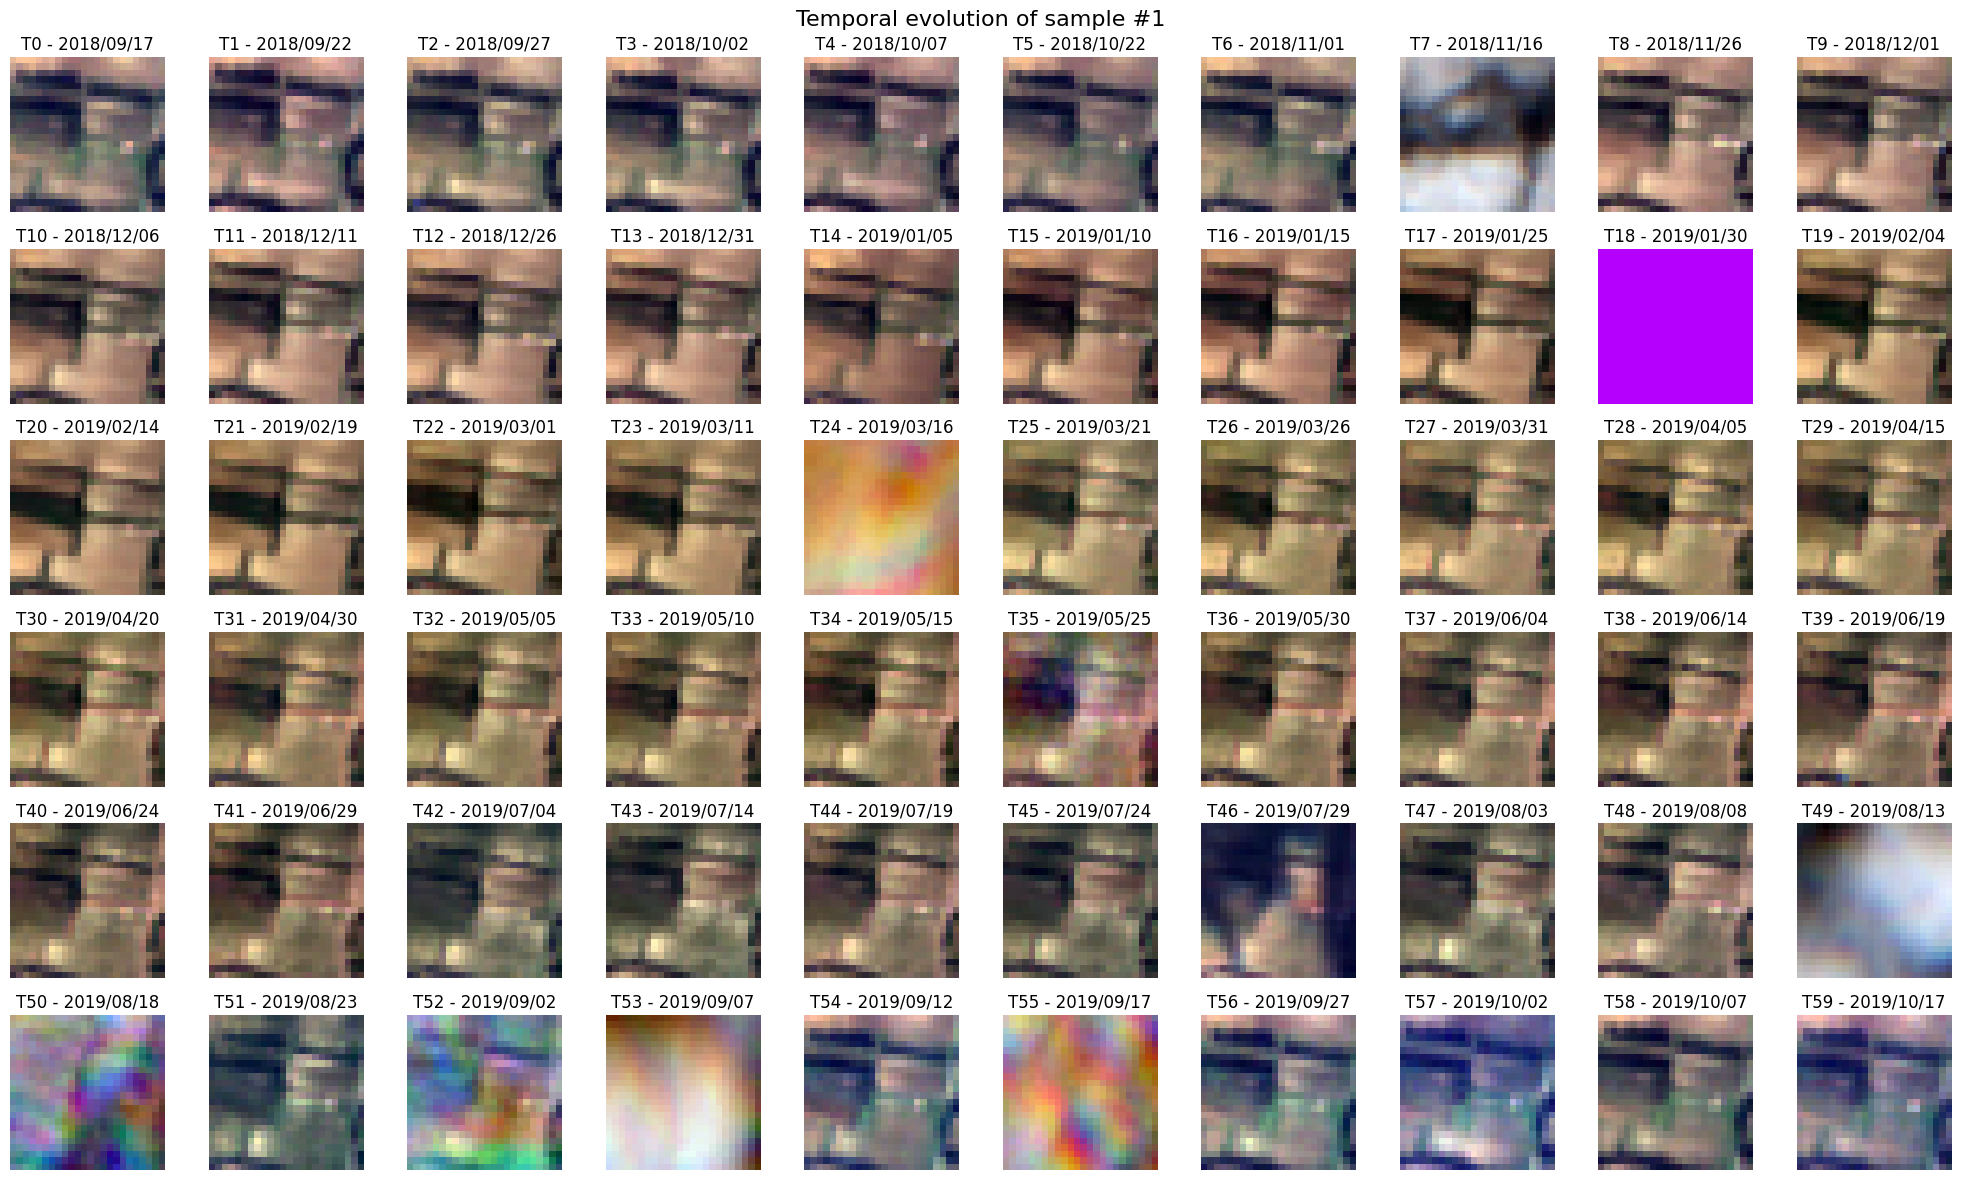

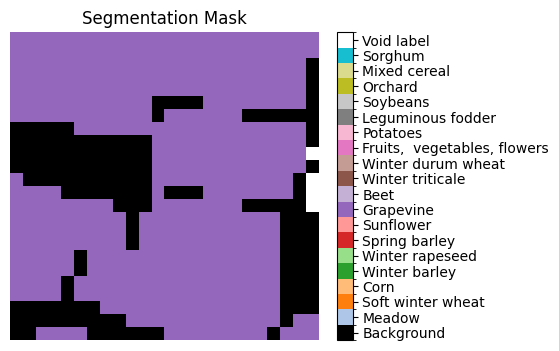

In [20]:
sample = next(iter(dataloaders['eval']))
sample_dict, texts, img_path = sample
sample_idx = random.randint(0, len(img_path)-1)
patch_id = 'UNKNOWN'
inputs = sample_dict['inputs']
labels = sample_dict['labels']
path_patch = img_path[sample_idx]
print(path_patch)
match = re.match(r"(\d+)_\d+\.pickle", os.path.basename(path_patch))
print(match)
if match:
    patch_id = match.group(1)
sample_labels = labels[sample_idx]
plot_sample_rgb(inputs, labels, patch_id, sample_idx=sample_idx)
plot_seg_mask(sample_labels[:, :, 0], colormap, label_names_en)

In [21]:
for text in texts:
    print(f"Text for patch {patch_id}:")
    if isinstance(text, str):
        print(text)
        print('\n\n')

Text for patch 20450:
A cultivated area with Meadow can be observed spanning approximately 29700 m2, Winter barley with a coverage of approximately 12500 m2 which equals a meaningful portion of the cultivated land in the region (approximately 57600 m2).

Regarding crop cultivation timings, Meadow was sown about October 20, 2018 and harvested in the end of March 2019. Along with that, the crop Winter barley was sown in mid-October 2018 and likely harvested in the midpoint of March 2019



Text for patch 20450:
This area has been identified with the crop of Grapevine with a dimension close to 42900 m2 which represents a significant portion of the total cultivated land.




Text for patch 20450:
A cultivated area with Soft winter wheat can be observed with an estimated surface of 24700 m2, Grapevine spanning approximately 9700 m2 which represents a significant portion of the total cultivated land (approximately 57600 m2).

Now, let's examine the planting and harvesting periods, the crop S